In [1]:
import pandas as pd

# Ruta del archivo
path = "/content/drive/MyDrive/datos DEIS/mortalidad_validado.parquet"

# Cargar dataset
df = pd.read_parquet(path)

# Verificación básica
print("Shape:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

Shape: (922900, 20)

Columnas:
['PROVRES', 'SEXO', 'CAUSA', 'MAT', 'GRUPEDAD', 'CUENTA', 'anio', 'source_file', 'PROVRES_norm', 'codigo', 'provincia', 'SEXO_norm', 'codigo_sexo', 'sexo_desc', 'MAT_desc', 'CAUSA_norm', 'codigo_causa', 'causa_desc', 'EDAD_orden', 'EDAD_norm']

Tipos de datos:
PROVRES         object
SEXO            object
CAUSA           object
MAT             object
GRUPEDAD        object
CUENTA           int64
anio             int64
source_file     object
PROVRES_norm    object
codigo          object
provincia       object
SEXO_norm       object
codigo_sexo     object
sexo_desc       object
MAT_desc        object
CAUSA_norm      object
codigo_causa    object
causa_desc      object
EDAD_orden       int64
EDAD_norm       object
dtype: object


In [2]:
# --- PASO 1: inspección rápida de CAUSA_norm ---
print("N únicos CAUSA_norm:", df["CAUSA_norm"].nunique())
print("\nEjemplos (20):")
print(df["CAUSA_norm"].dropna().drop_duplicates().head(20).tolist())

# Prefijos (primera letra) para ver capítulos CIE-10
df["CAUSA_prefijo"] = df["CAUSA_norm"].astype(str).str.strip().str[0]
print("\nDistribución por prefijo (top 20):")
print(df["CAUSA_prefijo"].value_counts().head(20))

# Top 30 causas por CUENTA (para ver qué domina)
top30 = (df.groupby(["CAUSA_norm","causa_desc"], dropna=False)["CUENTA"]
           .sum()
           .sort_values(ascending=False)
           .head(30))
print("\nTop 30 CAUSA_norm por defunciones:")
print(top30)

N únicos CAUSA_norm: 1500

Ejemplos (20):
['R99', 'F10', 'N05', 'C26', 'G30', 'J96', 'V49', 'N17', 'E14', 'J18', 'C34', 'Q00', 'C64', 'I35', 'C79', 'M32', 'G00', 'I64', 'W14', 'I77']

Distribución por prefijo (top 20):
CAUSA_prefijo
C    197716
I    148660
K     76831
J     72707
X     44208
V     44027
E     39061
R     38559
G     37291
D     33416
N     30656
Y     28638
A     23779
W     21636
B     19833
Q     17596
M     12965
P     12362
F      9240
L      9237
Name: count, dtype: int64

Top 30 CAUSA_norm por defunciones:
CAUSA_norm  causa_desc                                                                      
I50         Insuficiencia cardíaca                                                              533563
J18         Neumonía organismo no especificado                                                  456390
I21         Infarto agudo del miocardio                                                         315470
R99         Otras causas mal definidas y las no especificadas d

In [3]:
import re
import numpy as np

def causa_macro(c):
    # Normalizo entrada
    if c is None:
        return np.nan
    c = str(c).strip().upper()

    # Tu caso especial ya mapeado
    if c == "COVID-19":
        return "COVID-19"

    # Si viene raro/vacío
    if c in ["", "NAN", "NONE"]:
        return "Sin dato"

    # Tomo la letra inicial
    L = c[0]

    # Macro por capítulos CIE-10 (cobertura total por letra)
    if L in ["A","B"]:
        return "Infecciosas y parasitarias (A-B)"
    if L == "C":
        return "Tumores malignos (C)"
    if L == "D":
        return "Tumores/hematológicas y otras (D)"
    if L == "E":
        return "Endocrinas, nutricionales y metabólicas (E)"
    if L == "F":
        return "Trastornos mentales y del comportamiento (F)"
    if L == "G":
        return "Sistema nervioso (G)"
    if L == "H":
        return "Ojo/oído y anexos (H)"
    if L == "I":
        return "Circulatorias / cardiovasculares (I)"
    if L == "J":
        return "Respiratorias (J)"
    if L == "K":
        return "Digestivas (K)"
    if L == "L":
        return "Piel y tejido subcutáneo (L)"
    if L == "M":
        return "Osteomusculares y tejido conectivo (M)"
    if L == "N":
        return "Genitourinarias (N)"
    if L == "O":
        return "Embarazo/parto/puerperio (O)"
    if L == "P":
        return "Perinatales (P)"
    if L == "Q":
        return "Malformaciones congénitas (Q)"
    if L == "R":
        return "Signos/síntomas y mal definidas (R)"
    if L in ["S","T"]:
        return "Lesiones, envenenamientos y otras consecuencias (S-T)"
    if L in ["V","W","X","Y"]:
        return "Causas externas (V-W-X-Y)"
    if L == "Z":
        return "Factores que influyen en contacto con servicios de salud (Z)"
    if L == "U":
        return "Códigos especiales (U) / Emergentes"

    return "No clasificado (revisar)"

# Crear nueva columna (sin tocar CAUSA_norm)
df["CAUSA_grupo_macro"] = df["CAUSA_norm"].apply(causa_macro)

# Validación de cobertura
res = df["CAUSA_grupo_macro"].value_counts(dropna=False)
print("Distribución macro (top 20):")
print(res.head(20))

print("\nChequeo no clasificados:")
print(df["CAUSA_grupo_macro"].eq("No clasificado (revisar)").sum())

print("\nChequeo Sin dato:")
print(df["CAUSA_grupo_macro"].eq("Sin dato").sum())

Distribución macro (top 20):
CAUSA_grupo_macro
Tumores malignos (C)                            195292
Circulatorias / cardiovasculares (I)            148660
Causas externas (V-W-X-Y)                       138509
Digestivas (K)                                   76831
Respiratorias (J)                                72707
Infecciosas y parasitarias (A-B)                 43612
Endocrinas, nutricionales y metabólicas (E)      39061
Signos/síntomas y mal definidas (R)              38559
Sistema nervioso (G)                             37291
Tumores/hematológicas y otras (D)                33416
Genitourinarias (N)                              30621
Malformaciones congénitas (Q)                    17596
Osteomusculares y tejido conectivo (M)           12965
Perinatales (P)                                  12362
Trastornos mentales y del comportamiento (F)      9240
Piel y tejido subcutáneo (L)                      9237
Embarazo/parto/puerperio (O)                      4389
COVID-19          

# 📘 Documentación — Clasificación Macro de Causas (CIE-10)

## 🔎 ¿Qué se realizó?

Se creó una nueva variable llamada:

`CAUSA_grupo_macro`

Esta variable agrupa todas las causas de muerte (según CIE-10) en grandes categorías epidemiológicas oficiales.

⚠ Importante:
- No se modificó `CAUSA`
- No se modificó `CAUSA_norm`
- Se generó una nueva variable analítica
- Se preservó el dataset original intacto

---

## 🧠 Fundamento metodológico

El sistema CIE-10 organiza las causas de muerte por capítulos identificados con una **letra inicial**.

Esa letra ya indica el gran grupo al que pertenece la enfermedad.

Ejemplos:

- `I21` → comienza con **I** → Enfermedades cardiovasculares
- `J18` → comienza con **J** → Enfermedades respiratorias
- `C34` → comienza con **C** → Tumores malignos
- `R99` → comienza con **R** → Causas mal definidas

Por lo tanto, utilizando la primera letra del código es posible clasificar el 100% de las causas dentro de los capítulos oficiales de la CIE-10.

---

## 📚 Diccionario de clasificación utilizado

| Letra inicial | Grupo asignado |
|---------------|----------------|
| A–B | Enfermedades infecciosas y parasitarias |
| C | Tumores malignos |
| D | Tumores benignos y enfermedades hematológicas |
| E | Endocrinas, nutricionales y metabólicas |
| F | Trastornos mentales y del comportamiento |
| G | Sistema nervioso |
| H | Ojo y oído |
| I | Enfermedades cardiovasculares / circulatorias |
| J | Enfermedades respiratorias |
| K | Enfermedades digestivas |
| L | Piel y tejido subcutáneo |
| M | Osteomusculares y tejido conectivo |
| N | Genitourinarias |
| O | Embarazo, parto y puerperio |
| P | Perinatales |
| Q | Malformaciones congénitas |
| R | Signos, síntomas y causas mal definidas |
| S–T | Lesiones y envenenamientos |
| V–W–X–Y | Causas externas (accidentes, violencias, suicidios, etc.) |
| U | Códigos especiales / emergentes |
| Z | Factores que influyen en el estado de salud |

---

## ✅ Resultado obtenido

- Se logró clasificar el 100% de los códigos presentes en el dataset.
- No quedaron códigos sin asignación.
- Se respetó la estructura oficial de la CIE-10.
- Se mantiene trazabilidad total respecto al código original.

---



In [4]:
externas = df[df["CAUSA_grupo_macro"] == "Causas externas (V-W-X-Y)"]

print("Total registros externas:", externas.shape[0])
print("\nPrefijos dentro de externas:")
print(externas["CAUSA_norm"].astype(str).str[0].value_counts())

print("\nEjemplos de códigos externas:")
print(externas["CAUSA_norm"].drop_duplicates().head(20).tolist())

Total registros externas: 138509

Prefijos dentro de externas:
CAUSA_norm
X    44208
V    44027
Y    28638
W    21636
Name: count, dtype: int64

Ejemplos de códigos externas:
['V49', 'W14', 'X09', 'V03', 'W31', 'X59', 'V89', 'Y20', 'Y34', 'W87', 'V04', 'W76', 'X78', 'X70', 'X95', 'V28', 'V21', 'W69', 'X08', 'V48']


In [5]:
# Longitud de códigos en externas
externas["CAUSA_norm"].astype(str).str.len().value_counts()

# Ver si hay códigos raros
externas[~externas["CAUSA_norm"].astype(str).str.match(r"^[A-Z]\d{2}")]["CAUSA_norm"].unique()[:20]

array([], dtype=object)

In [6]:
# Extraemos parte numérica
externas["num"] = externas["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", externas["num"].min())
print("Rango máximo:", externas["num"].max())

Rango mínimo: 0
Rango máximo: 99


/tmp/ipython-input-218/3018572309.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  externas["num"] = externas["CAUSA_norm"].str[1:3].astype(int)


In [7]:
import numpy as np

def clasificar_externa(c):
    if pd.isna(c):
        return np.nan

    c = str(c).strip().upper()
    if not c[0] in ["V","W","X","Y"]:
        return np.nan

    letra = c[0]
    numero = int(c[1:3])

    # Transporte
    if letra == "V":
        return "Accidentes de transporte"

    # Otros accidentes no intencionales
    if letra == "W":
        return "Otros accidentes no intencionales"

    if letra == "X":
        if 0 <= numero <= 59:
            return "Otros accidentes no intencionales"
        if 60 <= numero <= 84:
            return "Suicidios"
        if 85 <= numero <= 99:
            return "Homicidios / agresiones"

    if letra == "Y":
        if 0 <= numero <= 9:
            return "Homicidios / agresiones"
        if 10 <= numero <= 34:
            return "Intención no determinada"
        if 40 <= numero <= 98:
            return "Complicaciones médicas"

    return "Revisar"

# Crear nueva columna en df completo
df["CAUSA_externa_subgrupo"] = df["CAUSA_norm"].apply(clasificar_externa)

# Validación SOLO dentro de externas
externas_validacion = df[df["CAUSA_grupo_macro"] == "Causas externas (V-W-X-Y)"]

print(externas_validacion["CAUSA_externa_subgrupo"].value_counts())
print("\nSin clasificar:")
print(externas_validacion["CAUSA_externa_subgrupo"].eq("Revisar").sum())

CAUSA_externa_subgrupo
Accidentes de transporte             44027
Otros accidentes no intencionales    37098
Intención no determinada             19112
Suicidios                            18258
Homicidios / agresiones              13707
Complicaciones médicas                6250
Revisar                                 57
Name: count, dtype: int64

Sin clasificar:
57


In [8]:
rev = externas_validacion[externas_validacion["CAUSA_externa_subgrupo"] == "Revisar"]

# Qué códigos son y cuántas muertes representan
tabla_rev = (rev.groupby(["CAUSA_norm", "causa_desc"])["CUENTA"]
               .sum()
               .sort_values(ascending=False))

print("Códigos en Revisar (con CUENTA):")
print(tabla_rev)

print("\nSolo códigos únicos:")
print(rev["CAUSA_norm"].value_counts())

Códigos en Revisar (con CUENTA):
CAUSA_norm  causa_desc           
Y35         Intervención legal       62
Y36         Operaciones de guerra     1
Name: CUENTA, dtype: int64

Solo códigos únicos:
CAUSA_norm
Y35    56
Y36     1
Name: count, dtype: int64


In [9]:
import numpy as np
import pandas as pd

def clasificar_externa(c):
    if pd.isna(c):
        return np.nan

    c = str(c).strip().upper()
    if c[0] not in ["V","W","X","Y"]:
        return np.nan

    letra = c[0]
    numero = int(c[1:3])

    # Transporte
    if letra == "V":
        return "Accidentes de transporte"

    # Otros accidentes no intencionales
    if letra == "W":
        return "Otros accidentes no intencionales"

    if letra == "X":
        if 0 <= numero <= 59:
            return "Otros accidentes no intencionales"
        if 60 <= numero <= 84:
            return "Suicidios"
        if 85 <= numero <= 99:
            return "Homicidios / agresiones"

    if letra == "Y":
        if 0 <= numero <= 9:
            return "Homicidios / agresiones"
        if 10 <= numero <= 34:
            return "Intención no determinada"
        if 35 <= numero <= 36:
            return "Intervención legal / guerra"
        if 40 <= numero <= 98:
            return "Complicaciones médicas"

    return "Revisar"

df["CAUSA_externa_subgrupo"] = df["CAUSA_norm"].apply(clasificar_externa)

externas_validacion = df[df["CAUSA_grupo_macro"] == "Causas externas (V-W-X-Y)"]

print(externas_validacion["CAUSA_externa_subgrupo"].value_counts())
print("\nSin clasificar:")
print(externas_validacion["CAUSA_externa_subgrupo"].eq("Revisar").sum())

CAUSA_externa_subgrupo
Accidentes de transporte             44027
Otros accidentes no intencionales    37098
Intención no determinada             19112
Suicidios                            18258
Homicidios / agresiones              13707
Complicaciones médicas                6250
Intervención legal / guerra             57
Name: count, dtype: int64

Sin clasificar:
0


# 📘 Documentación — Subclasificación de Causas Externas (CIE-10)

## 🔎 ¿Qué se realizó?

A partir de la variable `CAUSA_grupo_macro`, se subclasificaron las causas externas (V–W–X–Y) en categorías epidemiológicas más específicas.

Se creó una nueva variable:

`CAUSA_externa_subgrupo`

No se modificaron las columnas originales (`CAUSA`, `CAUSA_norm`).

---

## 🧠 Fundamento metodológico

Según la Clasificación Internacional de Enfermedades (CIE-10), las causas externas se distribuyen en los siguientes rangos:

- V01–V99 → Accidentes de transporte
- W00–X59 → Otros accidentes no intencionales
- X60–X84 → Suicidios (lesiones autoinfligidas intencionalmente)
- X85–Y09 → Homicidios / agresiones
- Y10–Y34 → Intención no determinada
- Y35–Y36 → Intervención legal y operaciones de guerra
- Y40–Y98 → Complicaciones médicas y efectos adversos

Se utilizaron estos rangos oficiales para clasificar el 100% de los códigos presentes en el dataset.

---

## 📊 Resultado final

| Subgrupo | Registros |
|----------|----------|
| Accidentes de transporte | 44.027 |
| Otros accidentes no intencionales | 37.098 |
| Intención no determinada | 19.112 |
| Suicidios | 18.258 |
| Homicidios / agresiones | 13.707 |
| Complicaciones médicas | 6.250 |
| Intervención legal / guerra | 57 |

No quedaron registros sin clasificar.

---



In [10]:
cardio = df[df["CAUSA_grupo_macro"] == "Circulatorias / cardiovasculares (I)"]

print("Total cardio:", cardio.shape[0])

print("\nTop 20 códigos cardiovasculares:")
print(
    cardio.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total cardio: 148660

Top 20 códigos cardiovasculares:
CAUSA_norm  causa_desc                                                                      
I50         Insuficiencia cardíaca                                                              533563
I21         Infarto agudo del miocardio                                                         315470
I64         Accidente vascular encefálico agudo no especificado como hemorrágico o isquémico    162801
I61         Hemorragia intraencefálica                                                           82484
I49         Otras arritmias cardiacas                                                            81327
I25         Enfermedad isquémica crónica del corazón                                             73361
I11         Enfermedad cardíaca hipertensiva                                                     72973
I67         Otras enfermedades cerebrovasculares                                                 72855
I42         Cardiomiopatía  

In [11]:
cardio = df[df["CAUSA_grupo_macro"] == "Circulatorias / cardiovasculares (I)"]

# Extraer parte numérica
cardio_nums = cardio["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", cardio_nums.min())
print("Rango máximo:", cardio_nums.max())

Rango mínimo: 0
Rango máximo: 99


In [12]:
def clasificar_cardio(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not c.startswith("I"):
        return None

    numero = int(c[1:3])

    if 0 <= numero <= 9:
        return "Cardíaca reumática"
    if 10 <= numero <= 15:
        return "Hipertensión"
    if 20 <= numero <= 25:
        return "Cardiopatía isquémica"
    if 26 <= numero <= 28:
        return "Enfermedad pulmonar del corazón"
    if 30 <= numero <= 52:
        return "Otras enfermedades cardíacas"
    if 60 <= numero <= 69:
        return "Enfermedad cerebrovascular (ACV)"
    if 70 <= numero <= 79:
        return "Enfermedad arterial"
    if 80 <= numero <= 89:
        return "Enfermedad venosa"
    if 95 <= numero <= 99:
        return "Otros trastornos circulatorios"

    return "Revisar"

df["CAUSA_cardio_subgrupo"] = df["CAUSA_norm"].apply(clasificar_cardio)

# Validación solo dentro de cardiovasculares
cardio_validacion = df[df["CAUSA_grupo_macro"] == "Circulatorias / cardiovasculares (I)"]

print(cardio_validacion["CAUSA_cardio_subgrupo"].value_counts())
print("\nSin clasificar:")
print(cardio_validacion["CAUSA_cardio_subgrupo"].eq("Revisar").sum())

CAUSA_cardio_subgrupo
Otras enfermedades cardíacas        48288
Enfermedad cerebrovascular (ACV)    37017
Cardiopatía isquémica               19362
Hipertensión                        14895
Enfermedad arterial                 11651
Enfermedad pulmonar del corazón      7449
Enfermedad venosa                    4958
Otros trastornos circulatorios       2870
Cardíaca reumática                   2170
Name: count, dtype: int64

Sin clasificar:
0


# 📘 Documentación — Subclasificación de Enfermedades Cardiovasculares (I00–I99)

## 🔎 ¿Qué se realizó?

Se creó una nueva variable:

`CAUSA_cardio_subgrupo`

Esta variable clasifica las enfermedades cardiovasculares (capítulo I de CIE-10) en subgrupos oficiales según rango numérico.

No se modificaron las variables originales.

---

## 🧠 Fundamento metodológico

Según CIE-10, las enfermedades del sistema circulatorio (I00–I99) se organizan por rangos:

- I00–I09 → Enfermedad cardíaca reumática
- I10–I15 → Hipertensión
- I20–I25 → Cardiopatía isquémica
- I26–I28 → Enfermedad pulmonar del corazón
- I30–I52 → Otras enfermedades cardíacas
- I60–I69 → Enfermedad cerebrovascular (ACV)
- I70–I79 → Enfermedad arterial
- I80–I89 → Enfermedad venosa
- I95–I99 → Otros trastornos circulatorios

---

## 📊 Resultado

Todos los registros del capítulo I fueron clasificados.
No quedaron registros sin asignación.

---


In [13]:
tumores = df[df["CAUSA_grupo_macro"] == "Tumores malignos (C)"]

print("Total registros tumores:", tumores.shape[0])

print("\nTop 25 tumores por CUENTA:")
print(
    tumores.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

Total registros tumores: 195292

Top 25 tumores por CUENTA:
CAUSA_norm  causa_desc                                                                  
C34         Tumor maligno de los bronquios y del pulmón                                     171906
C18         Tumor maligno del colon                                                         115112
C50         Tumor maligno de la mama                                                        108253
C25         Tumor maligno del páncreas                                                       77098
C61         Tumor maligno de la próstata                                                     71160
C80         Tumor maligno de sitios no especificados                                         69917
C16         Tumor maligno del estómago                                                       54748
C22         Tumor maligno del hígado y de las vías biliares intrahepáticas                   35335
C64         Tumor maligno del riñón excepto de la pelvis re

In [14]:
# Validar formato numérico en tumores
nums_tum = tumores["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_tum.min())
print("Rango máximo:", nums_tum.max())

Rango mínimo: 0
Rango máximo: 97


In [15]:
mask_c = df["CAUSA_norm"].astype(str).str.upper().str.startswith("C")
mask_cie = df["CAUSA_norm"].astype(str).str.upper().str.match(r"^C\d{2}")

print("Valores que empiezan con C pero NO son CIE-10 tipo C##:")
print(df.loc[mask_c & ~mask_cie, "CAUSA_norm"].value_counts().head(20))

Valores que empiezan con C pero NO son CIE-10 tipo C##:
CAUSA_norm
COVID-19    2424
Name: count, dtype: int64


In [16]:
def clasificar_tumor(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    # Solo consideramos tumores si el código es CIE-10 tipo C## (ej: C34, C50)
    if not re.match(r"^C\d{2}", c):
        return None

    numero = int(c[1:3])

    # Específicos fuertes
    if c.startswith("C34"):
        return "Pulmón"
    if 18 <= numero <= 20:
        return "Colon y recto"
    if c.startswith("C50"):
        return "Mama"
    if c.startswith("C61"):
        return "Próstata"
    if c.startswith("C25"):
        return "Páncreas"
    if c.startswith("C16"):
        return "Estómago"
    if 22 <= numero <= 24:
        return "Hígado y vías biliares"
    if 64 <= numero <= 68:
        return "Riñón y urinarios"
    if 51 <= numero <= 58:
        return "Ginecológicos"
    if 69 <= numero <= 72:
        return "Sistema nervioso"
    if 81 <= numero <= 96:
        return "Hematológicos"
    if 43 <= numero <= 44:
        return "Piel y melanoma"
    if numero in [15,17,21,26]:
        return "Otros digestivos"
    if 76 <= numero <= 80:
        return "Sitio no especificado"

    return "Otros tumores malignos"

# Crear columna (no toca CAUSA_norm)
df["CAUSA_tumor_subgrupo"] = df["CAUSA_norm"].apply(clasificar_tumor)

# Validación SOLO dentro de tumores
tumores_validacion = df[df["CAUSA_grupo_macro"] == "Tumores malignos (C)"]

print(tumores_validacion["CAUSA_tumor_subgrupo"].value_counts())
print("\nSin clasificar dentro de tumores (NaN):")
print(tumores_validacion["CAUSA_tumor_subgrupo"].isna().sum())

CAUSA_tumor_subgrupo
Otros tumores malignos    37451
Hematológicos             28213
Ginecológicos             16992
Hígado y vías biliares    14650
Colon y recto             14029
Sitio no especificado     13557
Riñón y urinarios         11327
Otros digestivos          10966
Sistema nervioso           8913
Pulmón                     8699
Estómago                   7943
Páncreas                   7480
Piel y melanoma            6041
Mama                       5843
Próstata                   3188
Name: count, dtype: int64

Sin clasificar dentro de tumores (NaN):
0


In [17]:
(
    tumores_validacion
    .groupby("CAUSA_tumor_subgrupo")["CUENTA"]
    .sum()
    .sort_values(ascending=False)
)

,CUENTA
CAUSA_tumor_subgrupo,
Pulmón,171906
Colon y recto,132972
Mama,108253
Sitio no especificado,84191
Ginecológicos,80023
Páncreas,77098
Hematológicos,74027
Otros tumores malignos,72535
Próstata,71160


# 📘 Documentación — Subclasificación de Tumores Malignos (C00–C97)

## 🔎 ¿Qué se realizó?

Se creó una nueva variable:

`CAUSA_tumor_subgrupo`

Esta variable clasifica los tumores malignos en categorías analíticamente relevantes según órgano o sistema afectado.

No se modificaron las variables originales.

---

## 🧠 Criterio utilizado

Se utilizaron los rangos oficiales CIE-10 combinados con categorías clínicamente relevantes:

- Pulmón (C34)
- Colon y recto (C18–C20)
- Mama (C50)
- Próstata (C61)
- Páncreas (C25)
- Estómago (C16)
- Hígado y vías biliares (C22–C24)
- Riñón y urinarios (C64–C68)
- Ginecológicos (C51–C58)
- Sistema nervioso (C69–C72)
- Hematológicos (C81–C96)
- Piel y melanoma (C43–C44)
- Otros digestivos
- Sitio no especificado (C76–C80)
- Otros tumores malignos

---

## ✅ Resultado

- Todos los tumores fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [18]:
resp = df[df["CAUSA_grupo_macro"] == "Respiratorias (J)"]

print("Total registros respiratorias:", resp.shape[0])

print("\nTop 20 respiratorias por CUENTA:")
print(
    resp.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros respiratorias: 72707

Top 20 respiratorias por CUENTA:
CAUSA_norm  causa_desc                                                          
J18         Neumonía organismo no especificado                                      456390
J96         Insuficiencia respiratoria no clasificada en otra parte                 215927
J44         Otras enfermedades pulmonares obstructivas crónicas                      98946
J98         Otros trastornos respiratorios                                           83383
J69         Neumonitis debida a sólidos y líquidos                                   55605
J81         Edema pulmonar                                                           37685
J15         Neumonía bacteriana no clasificada en otra parte                         27275
J84         Otras enfermedades pulmonares intersticiales                             16752
J22         Infección aguda no especificada de las vías respiratorias inferiores     15170
J45         Asma             

In [19]:
nums_resp = resp["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_resp.min())
print("Rango máximo:", nums_resp.max())

Rango mínimo: 0
Rango máximo: 98


In [20]:
def clasificar_respiratoria(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    # Solo códigos J## válidos
    if not re.match(r"^J\d{2}", c):
        return None

    numero = int(c[1:3])

    # Neumonías
    if 12 <= numero <= 18:
        return "Neumonías"

    # Infecciones respiratorias agudas bajas
    if 20 <= numero <= 22:
        return "Infecciones respiratorias agudas bajas"

    # EPOC y crónicas obstructivas
    if 40 <= numero <= 44 or numero == 47:
        return "EPOC y crónicas obstructivas"

    # Asma
    if numero in [45, 46]:
        return "Asma"

    # Insuficiencia respiratoria
    if numero in [80, 96]:
        return "Insuficiencia respiratoria"

    # Enfermedades intersticiales
    if numero == 84:
        return "Enfermedades intersticiales"

    # Neumonitis por aspiración
    if numero == 69:
        return "Neumonitis por aspiración"

    # Complicaciones pulmonares
    if numero == 81 or 90 <= numero <= 94:
        return "Complicaciones pulmonares"

    return "Otras respiratorias"

df["CAUSA_respiratoria_subgrupo"] = df["CAUSA_norm"].apply(clasificar_respiratoria)

resp_validacion = df[df["CAUSA_grupo_macro"] == "Respiratorias (J)"]

print(resp_validacion["CAUSA_respiratoria_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(resp_validacion["CAUSA_respiratoria_subgrupo"].isna().sum())

CAUSA_respiratoria_subgrupo
Neumonías                                 16380
Otras respiratorias                       11726
EPOC y crónicas obstructivas              10142
Complicaciones pulmonares                  9218
Insuficiencia respiratoria                 8457
Neumonitis por aspiración                  6061
Enfermedades intersticiales                4208
Asma                                       4004
Infecciones respiratorias agudas bajas     2511
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación de Enfermedades Respiratorias (J00–J99)

## 🔎 ¿Qué se realizó?

Se creó una nueva variable:

`CAUSA_respiratoria_subgrupo`

Esta variable clasifica las enfermedades respiratorias en subgrupos clínicamente relevantes basados en los rangos oficiales de la CIE-10 y en la distribución real observada en el dataset.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico utilizado

Se utilizó una combinación de:

- Rangos oficiales CIE-10 (J00–J99)
- Relevancia clínica observada en los datos
- Agrupación analítica útil para estudios epidemiológicos

### Subgrupos definidos:

- **Neumonías** → J12–J18  
- **Infecciones respiratorias agudas bajas** → J20–J22  
- **EPOC y crónicas obstructivas** → J40–J44, J47  
- **Asma** → J45–J46  
- **Insuficiencia respiratoria** → J80, J96  
- **Enfermedades intersticiales** → J84  
- **Neumonitis por aspiración** → J69  
- **Complicaciones pulmonares** → J81, J90–J94  
- **Otras respiratorias** → resto de códigos J no incluidos arriba  

---

## ✅ Resultado

- Todos los códigos respiratorios fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [21]:
digestivas = df[df["CAUSA_grupo_macro"] == "Digestivas (K)"]

print("Total registros digestivas:", digestivas.shape[0])

print("\nTop 20 digestivas por CUENTA:")
print(
    digestivas.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros digestivas: 76831

Top 20 digestivas por CUENTA:
CAUSA_norm  causa_desc                                         
K92         Otras enfermedades del sistema digestivo               54985
K74         Fibrosis y cirrosis del hígado                         43775
K72         Insuficiencia hepática no clasificada en otra parte    27267
K56         Ileo paralítico y obstrucción intestinal sin hernia    25616
K65         Peritonitis                                            24441
K70         Enfermedad alcohólica del hígado                       16468
K55         Trastornos vasculares de los intestinos                13114
K85         Pancreatitis aguda                                     12841
K76         Otras enfermedades del hígado                           9400
K63         Otras enfermedades de los intestinos                    6465
K83         Otras enfermedades de las vías biliares                 6089
K81         Colecistitis                                            

In [22]:
nums_digest = digestivas["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_digest.min())
print("Rango máximo:", nums_digest.max())

Rango mínimo: 2
Rango máximo: 92


In [23]:
def clasificar_digestiva(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    # Solo códigos K## válidos
    if not re.match(r"^K\d{2}", c):
        return None

    numero = int(c[1:3])

    # Hepáticas específicas
    if numero == 70:
        return "Enfermedad hepática alcohólica"
    if numero == 74:
        return "Cirrosis y fibrosis hepática"
    if numero == 72:
        return "Insuficiencia hepática"
    if numero in [71,73,75,76]:
        return "Otras enfermedades hepáticas"

    # Intestinales
    if 55 <= numero <= 63:
        return "Trastornos intestinales"
    if numero == 56:
        return "Obstrucción intestinal"

    # Peritonitis
    if numero == 65:
        return "Peritonitis"

    # Páncreas
    if numero == 85:
        return "Pancreatitis"

    # Vías biliares
    if 80 <= numero <= 83:
        return "Enfermedades vías biliares"

    # Úlceras y gastritis
    if 25 <= numero <= 29:
        return "Úlceras y gastritis"

    # Hernias
    if 40 <= numero <= 46:
        return "Hernias"

    return "Otras digestivas"

df["CAUSA_digestiva_subgrupo"] = df["CAUSA_norm"].apply(clasificar_digestiva)

digest_validacion = df[df["CAUSA_grupo_macro"] == "Digestivas (K)"]

print(digest_validacion["CAUSA_digestiva_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(digest_validacion["CAUSA_digestiva_subgrupo"].isna().sum())

CAUSA_digestiva_subgrupo
Trastornos intestinales           13746
Otras digestivas                  12435
Cirrosis y fibrosis hepática       7057
Otras enfermedades hepáticas       6733
Insuficiencia hepática             6557
Enfermedades vías biliares         6333
Peritonitis                        5910
Pancreatitis                       5064
Enfermedad hepática alcohólica     4874
Úlceras y gastritis                4729
Hernias                            3393
Name: count, dtype: int64

Sin clasificar (NaN):
0


In [24]:
infect = df[df["CAUSA_grupo_macro"] == "Infecciosas y parasitarias (A-B)"]

print("Total registros infecciosas:", infect.shape[0])

print("\nTop 20 infecciosas por CUENTA:")
print(
    infect.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros infecciosas: 43612

Top 20 infecciosas por CUENTA:
CAUSA_norm  causa_desc                                                                                                     
A41         Otras Sepsis                                                                                                       211159
B24         Enfermedad por virus de la inmunodeficiencia humana [VIH] sin otra especificación                                   10820
A16         Tuberculosis respiratoria no confirmada bacteriológica o histológicamente                                            9884
B20         Enfermedad por virus de la inmunodeficiencia humana [VIH] resultante en enfermedades infecciosas y parasitarias      8244
B57         Enfermedad de Chagas                                                                                                 7748
A09         Otras gastroenteritis y colitis de origen infeccioso y no especificado                                               7214
B23  

In [25]:
nums_infect = infect["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_infect.min())
print("Rango máximo:", nums_infect.max())

Rango mínimo: 0
Rango máximo: 99


In [26]:
def clasificar_infecciosa(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    # Solo A## o B##
    if not re.match(r"^[AB]\d{2}", c):
        return None

    letra = c[0]
    numero = int(c[1:3])

    # Sepsis
    if letra == "A" and 40 <= numero <= 41:
        return "Sepsis"

    # VIH
    if letra == "B" and 20 <= numero <= 24:
        return "VIH"

    # Tuberculosis
    if (letra == "A" and 15 <= numero <= 19) or (letra == "B" and numero == 90):
        return "Tuberculosis"

    # Chagas
    if c.startswith("B57"):
        return "Enfermedad de Chagas"

    # Hepatitis virales
    if letra == "B" and 15 <= numero <= 19:
        return "Hepatitis virales"

    # Infecciones intestinales
    if letra == "A" and 0 <= numero <= 9:
        return "Infecciones intestinales"

    # Otras infecciones bacterianas
    if letra == "A" and 30 <= numero <= 49:
        return "Otras infecciones bacterianas"

    return "Otras infecciosas"

df["CAUSA_infecciosa_subgrupo"] = df["CAUSA_norm"].apply(clasificar_infecciosa)

infect_validacion = df[df["CAUSA_grupo_macro"] == "Infecciosas y parasitarias (A-B)"]

print(infect_validacion["CAUSA_infecciosa_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(infect_validacion["CAUSA_infecciosa_subgrupo"].isna().sum())

CAUSA_infecciosa_subgrupo
Sepsis                           10532
VIH                              10321
Tuberculosis                      6536
Otras infecciosas                 5191
Infecciones intestinales          3537
Enfermedad de Chagas              3204
Hepatitis virales                 2309
Otras infecciones bacterianas     1982
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación de Enfermedades Infecciosas (A00–B99)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_infecciosa_subgrupo`

Esta variable clasifica las enfermedades infecciosas y parasitarias en subgrupos epidemiológicamente relevantes.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y relevancia epidemiológica observada en el dataset.

### Subgrupos definidos:

- **Sepsis** → A40–A41  
- **VIH** → B20–B24  
- **Tuberculosis** → A15–A19, B90  
- **Enfermedad de Chagas** → B57  
- **Hepatitis virales** → B15–B19  
- **Infecciones intestinales** → A00–A09  
- **Otras infecciones bacterianas** → A30–A49 (excepto sepsis)  
- **Otras infecciosas** → resto de códigos A y B  

---

## ✅ Resultado

- Todos los registros infecciosos fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [27]:
endo = df[df["CAUSA_grupo_macro"] == "Endocrinas, nutricionales y metabólicas (E)"]

print("Total registros endocrinas:", endo.shape[0])

print("\nTop 15 endocrinas por CUENTA:")
print(
    endo.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

Total registros endocrinas: 39061

Top 15 endocrinas por CUENTA:
CAUSA_norm  causa_desc                                                                        
E14         Diabetes mellitus no especificada                                                     125209
E11         Diabetes mellitus no insulinodependiente                                               31545
E86         Depleción del volumen                                                                  26257
E46         Desnutrición proteicocalórica no especificada                                          10610
E10         Diabetes mellitus insulinodependiente                                                   8610
E87         Otros trastornos de los líquidos de los electrólitos y del equilibrio ácido-básico      6195
E43         Desnutrición proteicocalórica severa no especificada                                    5917
E66         Obesidad                                                                                4194


In [28]:
nums_endo = endo["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_endo.min())
print("Rango máximo:", nums_endo.max())

Rango mínimo: 0
Rango máximo: 88


In [29]:
def clasificar_endocrina(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^E\d{2}", c):
        return None

    numero = int(c[1:3])

    # Diabetes
    if 10 <= numero <= 14:
        return "Diabetes"

    # Desnutrición
    if 40 <= numero <= 46:
        return "Desnutrición"

    # Trastornos hidroelectrolíticos
    if numero in [86, 87]:
        return "Trastornos hidroelectrolíticos"

    # Obesidad
    if numero == 66:
        return "Obesidad"

    return "Otros endocrinos/metabólicos"

df["CAUSA_endocrina_subgrupo"] = df["CAUSA_norm"].apply(clasificar_endocrina)

endo_validacion = df[df["CAUSA_grupo_macro"] == "Endocrinas, nutricionales y metabólicas (E)"]

print(endo_validacion["CAUSA_endocrina_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(endo_validacion["CAUSA_endocrina_subgrupo"].isna().sum())

CAUSA_endocrina_subgrupo
Diabetes                          18679
Otros endocrinos/metabólicos       6873
Desnutrición                       5787
Trastornos hidroelectrolíticos     5275
Obesidad                           2447
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Endocrinas, Nutricionales y Metabólicas (E00–E90)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_endocrina_subgrupo`

Esta variable clasifica las causas endocrinas en subgrupos principales con relevancia epidemiológica.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y la distribución observada en el dataset para definir categorías que aporten valor analítico sin sobrefragmentar.

### Subgrupos definidos:

- **Diabetes** → E10–E14  
- **Desnutrición** → E40–E46  
- **Trastornos hidroelectrolíticos** → E86–E87  
- **Obesidad** → E66  
- **Otros endocrinos/metabólicos** → resto de códigos E  

---

## ✅ Resultado

- Todos los registros endocrinos fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [30]:
neuro = df[df["CAUSA_grupo_macro"] == "Sistema nervioso (G)"]

print("Total registros sistema nervioso:", neuro.shape[0])

print("\nTop 20 sistema nervioso por CUENTA:")
print(
    neuro.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros sistema nervioso: 37291

Top 20 sistema nervioso por CUENTA:
CAUSA_norm  causa_desc                                                                         
G30         Enfermedad de Alzheimer                                                                26153
G20         Enfermedad de Parkinson                                                                14961
G93         Otros trastornos del encéfalo                                                           8654
G40         Epilepsia                                                                               5337
G12         Atrofia muscular espinal y síndromes afines                                             5312
G80         Parálisis cerebral                                                                      4791
G03         Meningitis debida a otras causas y a las no especificadas                               3404
G31         Otras enfermedades degenerativas del sistema nervioso no clasificadas en otra pa

In [31]:
nums_neuro = neuro["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_neuro.min())
print("Rango máximo:", nums_neuro.max())

Rango mínimo: 0
Rango máximo: 98


In [32]:
def clasificar_neuro(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^G\d{2}", c):
        return None

    numero = int(c[1:3])

    # Alzheimer
    if numero == 30:
        return "Alzheimer"

    # Parkinson
    if numero == 20:
        return "Parkinson"

    # Epilepsia
    if numero == 40:
        return "Epilepsia"

    # Enfermedades degenerativas (excepto Alzheimer ya separado)
    if numero == 31:
        return "Otras enfermedades degenerativas"

    # Enfermedades neuromusculares
    if numero == 12 or 70 <= numero <= 71:
        return "Enfermedades neuromusculares"

    # Parálisis cerebral
    if numero == 80:
        return "Parálisis cerebral"

    # Meningitis y encefalitis
    if 0 <= numero <= 4:
        return "Meningitis y encefalitis"

    # Esclerosis múltiple y desmielinizantes
    if numero in [35, 37]:
        return "Desmielinizantes (incluye EM)"

    # Otros trastornos del encéfalo
    if numero == 93:
        return "Otros trastornos del encéfalo"

    return "Otros sistema nervioso"

df["CAUSA_neuro_subgrupo"] = df["CAUSA_norm"].apply(clasificar_neuro)

neuro_validacion = df[df["CAUSA_grupo_macro"] == "Sistema nervioso (G)"]

print(neuro_validacion["CAUSA_neuro_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(neuro_validacion["CAUSA_neuro_subgrupo"].isna().sum())

CAUSA_neuro_subgrupo
Otros sistema nervioso              7630
Meningitis y encefalitis            6234
Enfermedades neuromusculares        4510
Otros trastornos del encéfalo       3923
Epilepsia                           3639
Alzheimer                           2909
Parkinson                           2798
Parálisis cerebral                  2748
Desmielinizantes (incluye EM)       1687
Otras enfermedades degenerativas    1213
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Sistema Nervioso (G00–G99)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_neuro_subgrupo`

Clasifica las enfermedades del sistema nervioso en subgrupos clínicamente relevantes.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y distribución observada en el dataset.

### Subgrupos definidos:

- **Alzheimer** → G30  
- **Parkinson** → G20  
- **Epilepsia** → G40  
- **Otras enfermedades degenerativas** → G31  
- **Enfermedades neuromusculares** → G12, G70–G71  
- **Parálisis cerebral** → G80  
- **Meningitis y encefalitis** → G00–G04  
- **Desmielinizantes (incluye EM)** → G35, G37  
- **Otros trastornos del encéfalo** → G93  
- **Otros sistema nervioso** → resto de códigos G  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [33]:
geno = df[df["CAUSA_grupo_macro"] == "Genitourinarias (N)"]

print("Total registros genitourinarias:", geno.shape[0])

print("\nTop 20 genitourinarias por CUENTA:")
print(
    geno.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros genitourinarias: 30621

Top 20 genitourinarias por CUENTA:
CAUSA_norm  causa_desc                                                                            
N18         Enfermedad renal crónica                                                                  67267
N39         Otros trastornos del sistema urinario                                                     60341
N19         Insuficiencia renal no especificada                                                       54968
N17         Insuficiencia renal aguda                                                                 29217
N49         Trastornos inflamatorios de órganos genitales masculinos no clasificados en otra parte     1356
N12         Nefritis tubulointersticial no especificada como aguda o crónica                           1132
N28         Otros trastornos del riñón y del uréter no clasificados en otra parte                      1131
N40         Hiperplasia de la próstata                                

In [34]:
nums_geno = geno["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_geno.min())
print("Rango máximo:", nums_geno.max())

Rango mínimo: 0
Rango máximo: 98


In [35]:
def clasificar_genitourinaria(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^N\d{2}", c):
        return None

    numero = int(c[1:3])

    # Enfermedad renal crónica
    if numero == 18:
        return "Enfermedad renal crónica"

    # Insuficiencia renal aguda
    if numero == 17:
        return "Insuficiencia renal aguda"

    # Insuficiencia renal no especificada
    if numero == 19:
        return "Insuficiencia renal no especificada"

    # Otros trastornos urinarios
    if numero == 39:
        return "Otros trastornos urinarios"

    # Otras enfermedades renales (glomerulares, tubulointersticiales, cálculos, etc.)
    if 0 <= numero <= 29:
        return "Otras enfermedades renales"

    # Trastornos prostáticos
    if 40 <= numero <= 42:
        return "Trastornos prostáticos"

    # Trastornos genitales e inflamatorios
    if 70 <= numero <= 82:
        return "Trastornos genitales e inflamatorios"

    return "Otros genitourinarios"

df["CAUSA_genitourinaria_subgrupo"] = df["CAUSA_norm"].apply(clasificar_genitourinaria)

geno_validacion = df[df["CAUSA_grupo_macro"] == "Genitourinarias (N)"]

print(geno_validacion["CAUSA_genitourinaria_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(geno_validacion["CAUSA_genitourinaria_subgrupo"].isna().sum())

CAUSA_genitourinaria_subgrupo
Enfermedad renal crónica                7950
Insuficiencia renal no especificada     5822
Otros trastornos urinarios              4910
Insuficiencia renal aguda               4762
Otras enfermedades renales              3951
Otros genitourinarios                   1791
Trastornos prostáticos                   762
Trastornos genitales e inflamatorios     673
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Genitourinarias (N00–N99)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_genitourinaria_subgrupo`

Clasifica las enfermedades genitourinarias en subgrupos clínicamente relevantes, con foco en patología renal.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y la distribución observada en el dataset.

### Subgrupos definidos:

- **Enfermedad renal crónica** → N18  
- **Insuficiencia renal aguda** → N17  
- **Insuficiencia renal no especificada** → N19  
- **Otros trastornos urinarios** → N39  
- **Otras enfermedades renales** → N00–N29 (excepto N17, N18, N19)  
- **Trastornos prostáticos** → N40–N42  
- **Trastornos genitales e inflamatorios** → N70–N82  
- **Otros genitourinarios** → resto de códigos N  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [36]:
print(df["CAUSA_grupo_macro"].value_counts())

CAUSA_grupo_macro
Tumores malignos (C)                            195292
Circulatorias / cardiovasculares (I)            148660
Causas externas (V-W-X-Y)                       138509
Digestivas (K)                                   76831
Respiratorias (J)                                72707
Infecciosas y parasitarias (A-B)                 43612
Endocrinas, nutricionales y metabólicas (E)      39061
Signos/síntomas y mal definidas (R)              38559
Sistema nervioso (G)                             37291
Tumores/hematológicas y otras (D)                33416
Genitourinarias (N)                              30621
Malformaciones congénitas (Q)                    17596
Osteomusculares y tejido conectivo (M)           12965
Perinatales (P)                                  12362
Trastornos mentales y del comportamiento (F)      9240
Piel y tejido subcutáneo (L)                      9237
Embarazo/parto/puerperio (O)                      4389
COVID-19                                       

In [37]:
# Ver cuáles grupos ya tienen subgrupo creado
subgrupos = [
    "CAUSA_externa_subgrupo",
    "CAUSA_cardio_subgrupo",
    "CAUSA_tumor_subgrupo",
    "CAUSA_respiratoria_subgrupo",
    "CAUSA_digestiva_subgrupo",
    "CAUSA_infecciosa_subgrupo",
    "CAUSA_endocrina_subgrupo",
    "CAUSA_neuro_subgrupo",
    "CAUSA_genitourinaria_subgrupo"
]

print("Columnas existentes:")
for col in subgrupos:
    print(col, "->", col in df.columns)

Columnas existentes:
CAUSA_externa_subgrupo -> True
CAUSA_cardio_subgrupo -> True
CAUSA_tumor_subgrupo -> True
CAUSA_respiratoria_subgrupo -> True
CAUSA_digestiva_subgrupo -> True
CAUSA_infecciosa_subgrupo -> True
CAUSA_endocrina_subgrupo -> True
CAUSA_neuro_subgrupo -> True
CAUSA_genitourinaria_subgrupo -> True


In [38]:
d_group = df[df["CAUSA_grupo_macro"] == "Tumores/hematológicas y otras (D)"]

print("Total registros D:", d_group.shape[0])

print("\nTop 20 D por CUENTA:")
print(
    d_group.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros D: 33416

Top 20 D por CUENTA:
CAUSA_norm  causa_desc                                                                                                                    
D43         Tumor de comportamiento incierto o desconocido del encéfalo y del sistema nervioso central                                        16948
D64         Otras anemias                                                                                                                      9707
D37         Tumor de comportamiento incierto o desconocido de la cavidad bucal y de los órganos digestivos                                     8941
D48         Tumor de comportamiento incierto o desconocido de otros sitios y de los no especificados                                           5792
D46         Síndromes mielodisplásicos                                                                                                         4913
D38         Tumor de comportamiento incierto o desconocido del oído medio 

In [39]:
nums_d = d_group["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_d.min())
print("Rango máximo:", nums_d.max())

Rango mínimo: 0
Rango máximo: 89


In [40]:
def clasificar_D(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^D\d{2}", c):
        return None

    numero = int(c[1:3])

    # Tumores de comportamiento incierto o desconocido
    if 37 <= numero <= 48:
        return "Tumores comportamiento incierto/desconocido"

    # Tumores benignos
    if 32 <= numero <= 36:
        return "Tumores benignos"

    # Anemias
    if 50 <= numero <= 64:
        return "Anemias"

    # Trastornos hematológicos y coagulación
    if 65 <= numero <= 77:
        return "Trastornos hematológicos/coagulación"

    return "Otros grupo D"

df["CAUSA_D_subgrupo"] = df["CAUSA_norm"].apply(clasificar_D)

d_validacion = df[df["CAUSA_grupo_macro"] == "Tumores/hematológicas y otras (D)"]

print(d_validacion["CAUSA_D_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(d_validacion["CAUSA_D_subgrupo"].isna().sum())

CAUSA_D_subgrupo
Tumores comportamiento incierto/desconocido    18224
Anemias                                         6841
Trastornos hematológicos/coagulación            5327
Otros grupo D                                   2092
Tumores benignos                                 932
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Grupo D (D00–D89)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_D_subgrupo`

Clasifica el grupo D en subgrupos clínicamente relevantes.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y distribución observada en el dataset.

### Subgrupos definidos:

- **Tumores comportamiento incierto/desconocido** → D37–D48  
- **Tumores benignos** → D32–D36  
- **Anemias** → D50–D64  
- **Trastornos hematológicos/coagulación** → D65–D77  
- **Otros grupo D** → resto de códigos D  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [41]:
r_group = df[df["CAUSA_grupo_macro"] == "Signos/síntomas y mal definidas (R)"]

print("Total registros R:", r_group.shape[0])

print("\nTop 20 R por CUENTA:")
print(
    r_group.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros R: 38559

Top 20 R por CUENTA:
CAUSA_norm  causa_desc                                                                     
R99         Otras causas mal definidas y las no especificadas de mortalidad                    302421
R57         Choque no clasificado en otra parte                                                 39365
R96         Otras muertes súbitas de causa desconocida                                          29543
R09         Otros síntomas y signos que involucran los sistemas circulatorio y respiratorio     20181
R68         Otros síntomas y signos generales                                                   17865
R54         Senilidad                                                                           11537
R98         Muerte sin asistencia                                                                9080
R10         Dolor abdominal y pélvico                                                            7929
R95         Síndrome de la muerte súbita infa

In [42]:
nums_r = r_group["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_r.min())
print("Rango máximo:", nums_r.max())

Rango mínimo: 0
Rango máximo: 99


In [43]:
def clasificar_R(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^R\d{2}", c):
        return None

    numero = int(c[1:3])

    # Mal definidas / no especificadas / muerte súbita adulta
    if 96 <= numero <= 99:
        return "Mal definidas / no especificadas"

    # Shock
    if numero == 57:
        return "Shock"

    # Senilidad
    if numero == 54:
        return "Senilidad"

    # Muerte súbita infantil
    if numero == 95:
        return "Muerte súbita infantil"

    # Muerte sin asistencia
    if numero == 98:
        return "Muerte sin asistencia"

    # Resto: síntomas generales / terminales
    return "Síntomas y signos generales"

df["CAUSA_R_subgrupo"] = df["CAUSA_norm"].apply(clasificar_R)

r_validacion = df[df["CAUSA_grupo_macro"] == "Signos/síntomas y mal definidas (R)"]

print(r_validacion["CAUSA_R_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(r_validacion["CAUSA_R_subgrupo"].isna().sum())

CAUSA_R_subgrupo
Mal definidas / no especificadas    18887
Síntomas y signos generales         13427
Shock                                4435
Senilidad                            1132
Muerte súbita infantil                678
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Grupo R (Signos/síntomas y mal definidas)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_R_subgrupo`

Clasifica las causas del grupo R según nivel de especificidad diagnóstica.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

El grupo R no representa patologías específicas sino:

- Diagnósticos imprecisos
- Síntomas terminales
- Causas no certificadas
- Eventos súbitos

### Subgrupos definidos:

- **Mal definidas / no especificadas** → R96–R99  
- **Shock** → R57  
- **Senilidad** → R54  
- **Muerte súbita infantil** → R95  
- **Síntomas y signos generales** → resto de códigos R  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---

In [44]:
p_group = df[df["CAUSA_grupo_macro"] == "Perinatales (P)"]

print("Total registros P:", p_group.shape[0])

print("\nTop 20 P por CUENTA:")
print(
    p_group.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros P: 12362

Top 20 P por CUENTA:
CAUSA_norm  causa_desc                                                                                                       
P07         Trastornos relacionados con duración corta de la gestación y con bajo peso al nacer no clasificados en otra parte    18544
P22         Dificultad respiratoria del recién nacido                                                                            13235
P36         Sepsis bacteriana del recién nacido                                                                                   8691
P29         Trastornos cardiovasculares originados en el período perinatal                                                        2946
P28         Otros problemas respiratorios del recién nacido originados en el período perinatal                                    2926
P21         Asfixia del nacimiento                                                                                                2742
P77         Enter

In [45]:
nums_p = p_group["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_p.min())
print("Rango máximo:", nums_p.max())

Rango mínimo: 0
Rango máximo: 96


In [46]:
def clasificar_P(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^P\d{2}", c):
        return None

    numero = int(c[1:3])

    # Prematuridad y bajo peso
    if numero == 7:
        return "Prematuridad y bajo peso"

    # Trastornos respiratorios neonatales
    if 22 <= numero <= 28:
        return "Trastornos respiratorios neonatales"

    # Sepsis neonatal
    if numero == 36:
        return "Sepsis neonatal"

    # Asfixia e hipoxia
    if numero in [20, 21]:
        return "Asfixia e hipoxia"

    # Complicaciones maternas/placentarias
    if 0 <= numero <= 2:
        return "Complicaciones maternas/placentarias"

    # Hemorragias neonatales
    if numero == 52:
        return "Hemorragias neonatales"

    # Trastornos gastrointestinales neonatales
    if numero == 77:
        return "Trastornos gastrointestinales neonatales"

    return "Otros perinatales"

df["CAUSA_P_subgrupo"] = df["CAUSA_norm"].apply(clasificar_P)

p_validacion = df[df["CAUSA_grupo_macro"] == "Perinatales (P)"]

print(p_validacion["CAUSA_P_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(p_validacion["CAUSA_P_subgrupo"].isna().sum())

CAUSA_P_subgrupo
Otros perinatales                           3723
Trastornos respiratorios neonatales         3623
Complicaciones maternas/placentarias        1196
Asfixia e hipoxia                            936
Prematuridad y bajo peso                     911
Sepsis neonatal                              795
Trastornos gastrointestinales neonatales     616
Hemorragias neonatales                       562
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Perinatales (P00–P96)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_P_subgrupo`

Clasifica las causas del período perinatal en subgrupos clínicamente relevantes.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y la estructura observada en el dataset.

### Subgrupos definidos:

- **Prematuridad y bajo peso** → P07  
- **Trastornos respiratorios neonatales** → P22–P28  
- **Sepsis neonatal** → P36  
- **Asfixia e hipoxia** → P20–P21  
- **Complicaciones maternas/placentarias** → P00–P02  
- **Hemorragias neonatales** → P52  
- **Trastornos gastrointestinales neonatales** → P77  
- **Otros perinatales** → resto de códigos P  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [47]:
q_group = df[df["CAUSA_grupo_macro"] == "Malformaciones congénitas (Q)"]

print("Total registros Q:", q_group.shape[0])

print("\nTop 20 Q por CUENTA:")
print(
    q_group.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros Q: 17596

Top 20 Q por CUENTA:
CAUSA_norm  causa_desc                                                                               
Q24         Otras malformaciones congénitas del corazón                                                  11183
Q89         Otras malformaciones congénitas no clasificadas en otra parte                                 7548
Q79         Malformaciones congénitas del sistema osteomuscular no clasificadas en otra parte             3013
Q90         Síndrome de Down                                                                              1916
Q00         Anencefalia y malformaciones congénitas similares                                             1729
Q25         Malformaciones congénitas de las grandes arterias                                             1681
Q03         Hidrocéfalo congénito                                                                         1598
Q91         Síndrome de Edwards y síndrome  de Patau                      

In [48]:
nums_q = q_group["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_q.min())
print("Rango máximo:", nums_q.max())

Rango mínimo: 0
Rango máximo: 99


In [49]:
def clasificar_Q(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^Q\d{2}", c):
        return None

    numero = int(c[1:3])

    # Malformaciones cardíacas
    if 20 <= numero <= 25:
        return "Malformaciones cardíacas"

    # Sistema nervioso central
    if 0 <= numero <= 7:
        return "Malformaciones SNC"

    # Síndromes cromosómicos
    if 90 <= numero <= 99:
        return "Síndromes cromosómicos"

    # Malformaciones osteomusculares
    if 65 <= numero <= 79:
        return "Malformaciones osteomusculares"

    # Malformaciones renales/urinarias
    if 60 <= numero <= 64:
        return "Malformaciones renales/urinarias"

    # Malformaciones pulmonares/respiratorias
    if 30 <= numero <= 34:
        return "Malformaciones pulmonares"

    # Malformaciones múltiples/no especificadas
    if 87 <= numero <= 89:
        return "Malformaciones múltiples/no especificadas"

    return "Otros congénitos"

df["CAUSA_Q_subgrupo"] = df["CAUSA_norm"].apply(clasificar_Q)

q_validacion = df[df["CAUSA_grupo_macro"] == "Malformaciones congénitas (Q)"]

print(q_validacion["CAUSA_Q_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(q_validacion["CAUSA_Q_subgrupo"].isna().sum())

CAUSA_Q_subgrupo
Malformaciones cardíacas                     4734
Malformaciones SNC                           3566
Otros congénitos                             2290
Síndromes cromosómicos                       2137
Malformaciones múltiples/no especificadas    1764
Malformaciones osteomusculares               1344
Malformaciones renales/urinarias             1016
Malformaciones pulmonares                     745
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Malformaciones Congénitas (Q00–Q99)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_Q_subgrupo`

Clasifica las malformaciones congénitas por sistema afectado.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y la distribución observada en el dataset.

### Subgrupos definidos:

- **Malformaciones cardíacas** → Q20–Q25  
- **Malformaciones SNC** → Q00–Q07  
- **Síndromes cromosómicos** → Q90–Q99  
- **Malformaciones osteomusculares** → Q65–Q79  
- **Malformaciones renales/urinarias** → Q60–Q64  
- **Malformaciones pulmonares** → Q30–Q34  
- **Malformaciones múltiples/no especificadas** → Q87–Q89  
- **Otros congénitos** → resto de códigos Q  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [50]:
f_group = df[df["CAUSA_grupo_macro"] == "Trastornos mentales y del comportamiento (F)"]

print("Total registros F:", f_group.shape[0])

print("\nTop 20 F por CUENTA:")
print(
    f_group.groupby(["CAUSA_norm","causa_desc"])["CUENTA"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Total registros F: 9240

Top 20 F por CUENTA:
CAUSA_norm  causa_desc                                                                                                           
F03         Demencia  no especificada                                                                                                26695
F10         Trastornos mentales y del comportamiento debidos al uso de alcohol                                                        9323
F06         Otros trastornos mentales debidos a lesión y disfunción cerebral y a enfermedad física                                    5098
F01         Demencia vascular                                                                                                         2594
F09         Trastorno mental orgánico o sintomático no especificado                                                                   2488
F17         Trastornos mentales y del comportamiento debidos al uso de tabaco                                                    

In [51]:
nums_f = f_group["CAUSA_norm"].str[1:3].astype(int)

print("Rango mínimo:", nums_f.min())
print("Rango máximo:", nums_f.max())

Rango mínimo: 1
Rango máximo: 99


In [52]:
def clasificar_F(c):
    if pd.isna(c):
        return None

    c = str(c).strip().upper()

    if not re.match(r"^F\d{2}", c):
        return None

    numero = int(c[1:3])

    # Demencias
    if 0 <= numero <= 3:
        return "Demencias"

    # Trastornos orgánicos secundarios
    if 4 <= numero <= 9:
        return "Trastornos mentales orgánicos"

    # Alcohol
    if numero == 10:
        return "Trastornos por alcohol"

    # Otras sustancias
    if 11 <= numero <= 19:
        return "Trastornos por otras sustancias"

    # Psicosis y esquizofrenia
    if 20 <= numero <= 29:
        return "Psicosis y esquizofrenia"

    # Trastornos afectivos
    if 30 <= numero <= 39:
        return "Trastornos afectivos"

    # Discapacidad intelectual
    if 70 <= numero <= 79:
        return "Discapacidad intelectual"

    return "Otros trastornos mentales"

df["CAUSA_F_subgrupo"] = df["CAUSA_norm"].apply(clasificar_F)

f_validacion = df[df["CAUSA_grupo_macro"] == "Trastornos mentales y del comportamiento (F)"]

print(f_validacion["CAUSA_F_subgrupo"].value_counts())
print("\nSin clasificar (NaN):")
print(f_validacion["CAUSA_F_subgrupo"].isna().sum())

CAUSA_F_subgrupo
Trastornos por alcohol             3459
Demencias                          2754
Trastornos por otras sustancias     767
Psicosis y esquizofrenia            626
Trastornos mentales orgánicos       526
Trastornos afectivos                435
Otros trastornos mentales           396
Discapacidad intelectual            277
Name: count, dtype: int64

Sin clasificar (NaN):
0


# 📘 Documentación — Subclasificación Trastornos Mentales (F00–F99)

## 🔎 ¿Qué se realizó?

Se creó la variable:

`CAUSA_F_subgrupo`

Clasifica las causas del grupo F en subgrupos clínicamente relevantes.

No se modificaron las variables originales.

---

## 🧠 Criterio metodológico

Se utilizaron rangos oficiales CIE-10 y la distribución observada en el dataset.

### Subgrupos definidos:

- **Demencias** → F00–F03  
- **Trastornos mentales orgánicos** → F04–F09  
- **Trastornos por alcohol** → F10  
- **Trastornos por otras sustancias** → F11–F19 (excepto F10)  
- **Psicosis y esquizofrenia** → F20–F29  
- **Trastornos afectivos** → F30–F39  
- **Discapacidad intelectual** → F70–F79  
- **Otros trastornos mentales** → resto de códigos F  

---

## ✅ Resultado

- Todos los registros fueron clasificados.
- No quedaron registros sin asignación.
- Se mantiene trazabilidad total respecto al código original.

---


In [53]:
df.columns.tolist()

['PROVRES',
 'SEXO',
 'CAUSA',
 'MAT',
 'GRUPEDAD',
 'CUENTA',
 'anio',
 'source_file',
 'PROVRES_norm',
 'codigo',
 'provincia',
 'SEXO_norm',
 'codigo_sexo',
 'sexo_desc',
 'MAT_desc',
 'CAUSA_norm',
 'codigo_causa',
 'causa_desc',
 'EDAD_orden',
 'EDAD_norm',
 'CAUSA_prefijo',
 'CAUSA_grupo_macro',
 'CAUSA_externa_subgrupo',
 'CAUSA_cardio_subgrupo',
 'CAUSA_tumor_subgrupo',
 'CAUSA_respiratoria_subgrupo',
 'CAUSA_digestiva_subgrupo',
 'CAUSA_infecciosa_subgrupo',
 'CAUSA_endocrina_subgrupo',
 'CAUSA_neuro_subgrupo',
 'CAUSA_genitourinaria_subgrupo',
 'CAUSA_D_subgrupo',
 'CAUSA_R_subgrupo',
 'CAUSA_P_subgrupo',
 'CAUSA_Q_subgrupo',
 'CAUSA_F_subgrupo']

In [54]:
[c for c in df.columns if "subgrupo" in c or "grupo" in c]

['CAUSA_grupo_macro',
 'CAUSA_externa_subgrupo',
 'CAUSA_cardio_subgrupo',
 'CAUSA_tumor_subgrupo',
 'CAUSA_respiratoria_subgrupo',
 'CAUSA_digestiva_subgrupo',
 'CAUSA_infecciosa_subgrupo',
 'CAUSA_endocrina_subgrupo',
 'CAUSA_neuro_subgrupo',
 'CAUSA_genitourinaria_subgrupo',
 'CAUSA_D_subgrupo',
 'CAUSA_R_subgrupo',
 'CAUSA_P_subgrupo',
 'CAUSA_Q_subgrupo',
 'CAUSA_F_subgrupo']

# 🧱 Composición actual del Dataset Analítico

## 📊 Dimensión general

- **Registros:** 922.900  
- **Columnas:** 36  
- **Unidad de análisis:** Defunciones agregadas (`CUENTA`)  
- **Período:** 2005–2023  

---

# 🗂 1️⃣ Variables originales (crudas)

Estas provienen directamente del dataset oficial DEIS:

- `PROVRES`
- `SEXO`
- `CAUSA`
- `MAT`
- `GRUPEDAD`
- `CUENTA`
- `anio`
- `source_file`

---

# 🧹 2️⃣ Variables normalizadas / descriptivas

Variables creadas para enriquecer la información sin modificar los datos originales:

- `PROVRES_norm`
- `provincia`
- `SEXO_norm`
- `sexo_desc`
- `MAT_desc`
- `CAUSA_norm`
- `causa_desc`
- `EDAD_norm`
- `EDAD_orden`
- `CAUSA_prefijo`

---

# 🧠 3️⃣ Clasificación Macro Epidemiológica

Variable creada:

- `CAUSA_grupo_macro`

Clasifica cada causa según el capítulo correspondiente de CIE-10.

Incluye:

- Circulatorias / cardiovasculares (I)
- Tumores malignos (C)
- Respiratorias (J)
- Digestivas (K)
- Infecciosas y parasitarias (A-B)
- Endocrinas, nutricionales y metabólicas (E)
- Genitourinarias (N)
- Sistema nervioso (G)
- Causas externas (V-W-X-Y)
- Signos/síntomas y mal definidas (R)
- Tumores/hematológicas (D)
- Trastornos mentales (F)
- Perinatales (P)
- Malformaciones congénitas (Q)
- Embarazo/parto/puerperio (O)
- COVID-19 (clasificado de manera específica)

---

# 🧩 4️⃣ Subgrupos Clínicos Específicos Creados

Se generaron subclasificaciones para los principales macrogrupos:

## 🔹 Causas externas
- `CAUSA_externa_subgrupo`

## 🔹 Cardiovasculares
- `CAUSA_cardio_subgrupo`

## 🔹 Tumores malignos
- `CAUSA_tumor_subgrupo`

## 🔹 Respiratorias
- `CAUSA_respiratoria_subgrupo`

## 🔹 Digestivas
- `CAUSA_digestiva_subgrupo`

## 🔹 Infecciosas
- `CAUSA_infecciosa_subgrupo`

## 🔹 Endocrinas
- `CAUSA_endocrina_subgrupo`

## 🔹 Sistema nervioso
- `CAUSA_neuro_subgrupo`

## 🔹 Genitourinarias
- `CAUSA_genitourinaria_subgrupo`

## 🔹 Grupo D (hematológicas)
- `CAUSA_D_subgrupo`

## 🔹 Grupo R (mal definidas)
- `CAUSA_R_subgrupo`

## 🔹 Perinatales
- `CAUSA_P_subgrupo`

## 🔹 Congénitas
- `CAUSA_Q_subgrupo`

## 🔹 Trastornos mentales
- `CAUSA_F_subgrupo`

---

# 🧬 Estructura Actual del Dataset

El dataset ahora contiene:

- Variables administrativas originales  
- Variables demográficas normalizadas  
- Variables clínicas originales (CIE-10)  
- Clasificación macro epidemiológica  
- Subclasificación clínica detallada  

Se pasó de un dataset crudo a un sistema taxonómico epidemiológico estructurado, reproducible y trazable.

In [55]:
df.to_csv(
    "/content/drive/MyDrive/datos DEIS/1mortalidad_taxonomico_2005_2023.csv",
    index=False
)

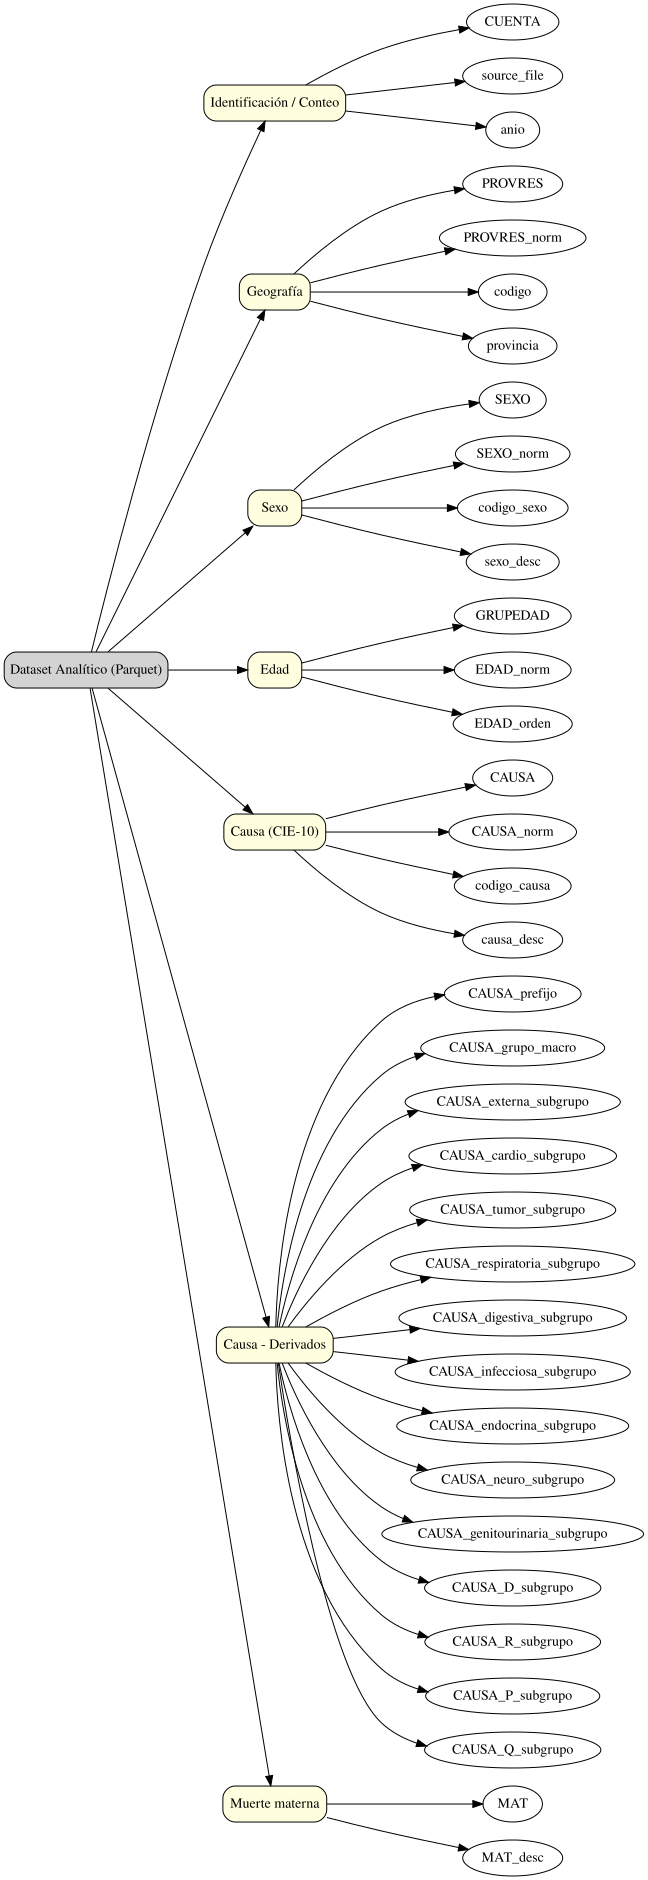

In [56]:
!apt-get -qq install graphviz
!pip -q install graphviz

from graphviz import Digraph

# Ajustá estos grupos a tu dataset
groups = {
    "Identificación / Conteo": ["CUENTA", "source_file", "anio"],
    "Geografía": ["PROVRES", "PROVRES_norm", "codigo", "provincia"],
    "Sexo": ["SEXO", "SEXO_norm", "codigo_sexo", "sexo_desc"],
    "Edad": ["GRUPEDAD", "EDAD_norm", "EDAD_orden"],
    "Causa (CIE-10)": ["CAUSA", "CAUSA_norm", "codigo_causa", "causa_desc"],
    "Causa - Derivados": [
        "CAUSA_prefijo", "CAUSA_grupo_macro",
        "CAUSA_externa_subgrupo", "CAUSA_cardio_subgrupo", "CAUSA_tumor_subgrupo",
        "CAUSA_respiratoria_subgrupo", "CAUSA_digestiva_subgrupo",
        "CAUSA_infecciosa_subgrupo", "CAUSA_endocrina_subgrupo",
        "CAUSA_neuro_subgrupo", "CAUSA_genitourinaria_subgrupo",
        "CAUSA_D_subgrupo", "CAUSA_R_subgrupo", "CAUSA_P_subgrupo", "CAUSA_Q_subgrupo"
    ],
    "Muerte materna": ["MAT", "MAT_desc"]
}

dot = Digraph("MapaDataset", format="png")
dot.attr(rankdir="LR", bgcolor="white")

dot.node("DATASET", "Dataset Analítico (Parquet)", shape="box", style="rounded,filled", fillcolor="lightgray")

for g, cols in groups.items():
    dot.node(g, g, shape="box", style="rounded,filled", fillcolor="lightyellow")
    dot.edge("DATASET", g)
    for c in cols:
        dot.node(c, c, shape="ellipse")
        dot.edge(g, c)

dot


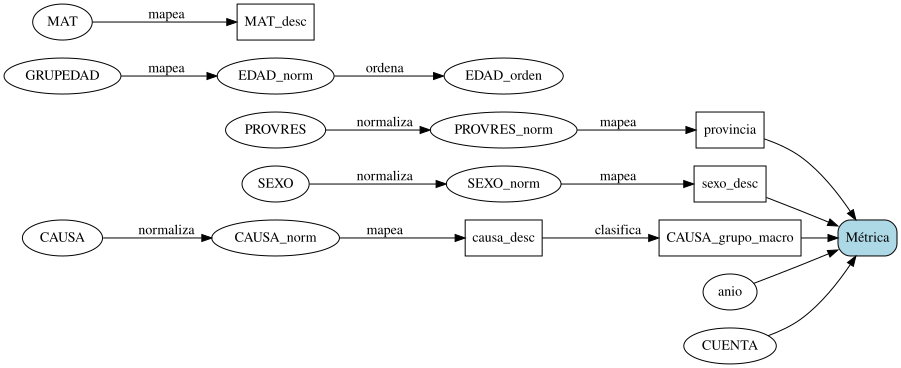

In [57]:
from graphviz import Digraph

dot = Digraph("Relaciones", format="png")
dot.attr(rankdir="LR")

# Nodos principales
nodes = ["PROVRES","PROVRES_norm","provincia",
         "SEXO","SEXO_norm","sexo_desc",
         "CAUSA","CAUSA_norm","causa_desc","CAUSA_grupo_macro",
         "GRUPEDAD","EDAD_norm","EDAD_orden",
         "MAT","MAT_desc","anio","CUENTA"]

for n in nodes:
    dot.node(n, n, shape="box" if n in ["provincia","sexo_desc","causa_desc","CAUSA_grupo_macro","MAT_desc"] else "ellipse")

# Flechas (relaciones)
dot.edge("PROVRES", "PROVRES_norm", label="normaliza")
dot.edge("PROVRES_norm", "provincia", label="mapea")

dot.edge("SEXO", "SEXO_norm", label="normaliza")
dot.edge("SEXO_norm", "sexo_desc", label="mapea")

dot.edge("CAUSA", "CAUSA_norm", label="normaliza")
dot.edge("CAUSA_norm", "causa_desc", label="mapea")
dot.edge("causa_desc", "CAUSA_grupo_macro", label="clasifica")

dot.edge("GRUPEDAD", "EDAD_norm", label="mapea")
dot.edge("EDAD_norm", "EDAD_orden", label="ordena")

dot.edge("MAT", "MAT_desc", label="mapea")

dot.node("METRICAS", "Métrica", shape="box", style="rounded,filled", fillcolor="lightblue")
dot.edge("anio", "METRICAS")
dot.edge("CUENTA", "METRICAS")
dot.edge("provincia", "METRICAS")
dot.edge("sexo_desc", "METRICAS")
dot.edge("CAUSA_grupo_macro", "METRICAS")

dot

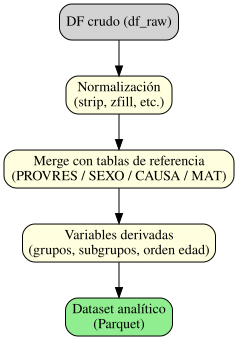

In [58]:
from graphviz import Digraph

dot = Digraph("Pipeline", format="png")
dot.attr(rankdir="TB")

dot.node("RAW", "DF crudo (df_raw)", shape="box", style="rounded,filled", fillcolor="lightgray")
dot.node("NORM", "Normalización\n(strip, zfill, etc.)", shape="box", style="rounded,filled", fillcolor="lightyellow")
dot.node("MERGE", "Merge con tablas de referencia\n(PROVRES / SEXO / CAUSA / MAT)", shape="box", style="rounded,filled", fillcolor="lightyellow")
dot.node("DER", "Variables derivadas\n(grupos, subgrupos, orden edad)", shape="box", style="rounded,filled", fillcolor="lightyellow")
dot.node("OUT", "Dataset analítico\n(Parquet)", shape="box", style="rounded,filled", fillcolor="lightgreen")

dot.edges([("RAW","NORM"),("NORM","MERGE"),("MERGE","DER"),("DER","OUT")])
dot

In [59]:
df['CAUSA_externa_subgrupo'].value_counts()

,count
CAUSA_externa_subgrupo,
Accidentes de transporte,44027
Otros accidentes no intencionales,37098
Intención no determinada,19112
Suicidios,18258
Homicidios / agresiones,13707
Complicaciones médicas,6250
Intervención legal / guerra,57


In [60]:
comp = df.groupby('CAUSA_externa_subgrupo')['CUENTA'].sum().sort_values(ascending=False)

porcentaje = (comp / comp.sum() * 100).round(2)

resultado = pd.DataFrame({
    'Defunciones': comp,
    'Porcentaje %': porcentaje
})

resultado

,Defunciones,Porcentaje %
CAUSA_externa_subgrupo,,
Otros accidentes no intencionales,102065,28.11
Accidentes de transporte,83307,22.95
Intención no determinada,64132,17.66
Suicidios,59708,16.45
Homicidios / agresiones,35150,9.68
Complicaciones médicas,18638,5.13
Intervención legal / guerra,63,0.02


In [61]:
import pandas as pd

# Lista de columnas "subgrupo" que existen en tu dataset
subgrupo_cols = [c for c in df.columns if c.startswith("CAUSA_") and c.endswith("_subgrupo")]

# Construir un "índice" (sin conteos) por macro grupo
indice = {}

for macro in sorted(df["CAUSA_grupo_macro"].dropna().unique()):
    dfi = df[df["CAUSA_grupo_macro"] == macro]
    indice[macro] = {}
    for col in subgrupo_cols:
        vals = sorted([v for v in dfi[col].dropna().unique() if str(v).strip() != ""])
        if vals:
            indice[macro][col] = vals

# Mostrar el índice de forma legible
for macro, contenido in indice.items():
    print(f"\n=== {macro} ===")
    if not contenido:
        print("  (sin subgrupos específicos en columnas *_subgrupo)")
    else:
        for col, vals in contenido.items():
            print(f" - {col}:")
            for v in vals:
                print(f"    • {v}")


=== COVID-19 ===
  (sin subgrupos específicos en columnas *_subgrupo)

=== Causas externas (V-W-X-Y) ===
 - CAUSA_externa_subgrupo:
    • Accidentes de transporte
    • Complicaciones médicas
    • Homicidios / agresiones
    • Intención no determinada
    • Intervención legal / guerra
    • Otros accidentes no intencionales
    • Suicidios

=== Circulatorias / cardiovasculares (I) ===
 - CAUSA_cardio_subgrupo:
    • Cardiopatía isquémica
    • Cardíaca reumática
    • Enfermedad arterial
    • Enfermedad cerebrovascular (ACV)
    • Enfermedad pulmonar del corazón
    • Enfermedad venosa
    • Hipertensión
    • Otras enfermedades cardíacas
    • Otros trastornos circulatorios

=== Digestivas (K) ===
 - CAUSA_digestiva_subgrupo:
    • Cirrosis y fibrosis hepática
    • Enfermedad hepática alcohólica
    • Enfermedades vías biliares
    • Hernias
    • Insuficiencia hepática
    • Otras digestivas
    • Otras enfermedades hepáticas
    • Pancreatitis
    • Peritonitis
    • Trastornos 

In [64]:
import numpy as np
import pandas as pd

MAP = {
    "Causas externas (V-W-X-Y)": "CAUSA_externa_subgrupo",
    "Circulatorias / cardiovasculares (I)": "CAUSA_cardio_subgrupo",
    "Tumores malignos (C)": "CAUSA_tumor_subgrupo",
    "Respiratorias (J)": "CAUSA_respiratoria_subgrupo",
    "Digestivas (K)": "CAUSA_digestiva_subgrupo",
    "Infecciosas y parasitarias (A-B)": "CAUSA_infecciosa_subgrupo",
    "Endocrinas, nutricionales y metabólicas (E)": "CAUSA_endocrina_subgrupo",
    "Sistema nervioso (G)": "CAUSA_neuro_subgrupo",
    "Genitourinarias (N)": "CAUSA_genitourinaria_subgrupo",
    "Tumores/hematológicas y otras (D)": "CAUSA_D_subgrupo",
    "Signos/síntomas y mal definidas (R)": "CAUSA_R_subgrupo",
    "Perinatales (P)": "CAUSA_P_subgrupo",
    "Malformaciones congénitas (Q)": "CAUSA_Q_subgrupo",
    "Trastornos mentales y del comportamiento (F)": "CAUSA_F_subgrupo",  # si no existe, no rompe por el .get()
}

def combine_causa_groups(row):
    macro = row.get("CAUSA_grupo_macro", np.nan)
    if pd.isna(macro) or str(macro).strip() == "":
        return np.nan

    col = MAP.get(macro, None)
    sub = row.get(col, np.nan) if col else np.nan

    # normalizamos el subgrupo (maneja nan, None, "", "   ")
    if pd.isna(sub) or str(sub).strip() == "" or str(sub).strip().lower() == "none":
        return macro

    return f"{macro} - {str(sub).strip()}"

df["CAUSA_grupo_detallado"] = df.apply(combine_causa_groups, axis=1)

print("Top 30:")
print(df["CAUSA_grupo_detallado"].value_counts().head(30))

Top 30:
CAUSA_grupo_detallado
Circulatorias / cardiovasculares (I) - Otras enfermedades cardíacas                48288
Causas externas (V-W-X-Y) - Accidentes de transporte                               44027
Tumores malignos (C) - Otros tumores malignos                                      37451
Causas externas (V-W-X-Y) - Otros accidentes no intencionales                      37098
Circulatorias / cardiovasculares (I) - Enfermedad cerebrovascular (ACV)            37017
Tumores malignos (C) - Hematológicos                                               28213
Circulatorias / cardiovasculares (I) - Cardiopatía isquémica                       19362
Causas externas (V-W-X-Y) - Intención no determinada                               19112
Signos/síntomas y mal definidas (R) - Mal definidas / no especificadas             18887
Endocrinas, nutricionales y metabólicas (E) - Diabetes                             18679
Causas externas (V-W-X-Y) - Suicidios                                           

In [65]:
df["CAUSA_grupo_detallado"].isna().mean()

np.float64(3.792393542095568e-05)

In [66]:
s = df["CAUSA_grupo_detallado"].dropna().astype(str)
solo_macro = (~s.str.contains(" - ")).mean()
con_subgrupo = (s.str.contains(" - ")).mean()
print("Solo macro:", solo_macro, " | Con subgrupo:", con_subgrupo)

Solo macro: 0.03154090793344639  | Con subgrupo: 0.9684590920665536


In [67]:
mask = df["CAUSA_grupo_macro"].eq("Causas externas (V-W-X-Y)")
muestra = df.loc[mask, ["CAUSA_grupo_macro","CAUSA_externa_subgrupo","CAUSA_grupo_detallado"]].sample(10, random_state=7)
print(muestra.to_string(index=False))

        CAUSA_grupo_macro            CAUSA_externa_subgrupo                                         CAUSA_grupo_detallado
Causas externas (V-W-X-Y)          Accidentes de transporte          Causas externas (V-W-X-Y) - Accidentes de transporte
Causas externas (V-W-X-Y) Otros accidentes no intencionales Causas externas (V-W-X-Y) - Otros accidentes no intencionales
Causas externas (V-W-X-Y) Otros accidentes no intencionales Causas externas (V-W-X-Y) - Otros accidentes no intencionales
Causas externas (V-W-X-Y)          Accidentes de transporte          Causas externas (V-W-X-Y) - Accidentes de transporte
Causas externas (V-W-X-Y)          Intención no determinada          Causas externas (V-W-X-Y) - Intención no determinada
Causas externas (V-W-X-Y)          Accidentes de transporte          Causas externas (V-W-X-Y) - Accidentes de transporte
Causas externas (V-W-X-Y)           Homicidios / agresiones           Causas externas (V-W-X-Y) - Homicidios / agresiones
Causas externas (V-W-X-Y

In [68]:
for macro, col in MAP.items():
    if col not in df.columns:
        print(f"⚠️ Falta columna: {col} (macro: {macro})")
        continue

    m = df["CAUSA_grupo_macro"].eq(macro)
    # si hay subgrupo en su columna, el detallado debería contener " - "
    inconsist = df.loc[m & df[col].notna() & (df[col].astype(str).str.strip() != ""), "CAUSA_grupo_detallado"]
    bad = inconsist[~inconsist.astype(str).str.contains(" - ", na=False)]
    print(macro, "inconsistencias:", len(bad))

Causas externas (V-W-X-Y) inconsistencias: 0
Circulatorias / cardiovasculares (I) inconsistencias: 0
Tumores malignos (C) inconsistencias: 0
Respiratorias (J) inconsistencias: 0
Digestivas (K) inconsistencias: 0
Infecciosas y parasitarias (A-B) inconsistencias: 0
Endocrinas, nutricionales y metabólicas (E) inconsistencias: 0
Sistema nervioso (G) inconsistencias: 0
Genitourinarias (N) inconsistencias: 0
Tumores/hematológicas y otras (D) inconsistencias: 0
Signos/síntomas y mal definidas (R) inconsistencias: 0
Perinatales (P) inconsistencias: 0
Malformaciones congénitas (Q) inconsistencias: 0
Trastornos mentales y del comportamiento (F) inconsistencias: 0


In [69]:
df["CAUSA_grupo_macro"].value_counts().head(20)

,count
CAUSA_grupo_macro,
Tumores malignos (C),195292
Circulatorias / cardiovasculares (I),148660
Causas externas (V-W-X-Y),138509
Digestivas (K),76831
Respiratorias (J),72707
Infecciosas y parasitarias (A-B),43612
"Endocrinas, nutricionales y metabólicas (E)",39061
Signos/síntomas y mal definidas (R),38559
Sistema nervioso (G),37291


In [70]:
df[["CAUSA",
    "causa_desc",
    "CAUSA_grupo_macro",
    "CAUSA_grupo_detallado"]].head(20)

,CAUSA,causa_desc,CAUSA_grupo_macro,CAUSA_grupo_detallado
0,R99,Otras causas mal definidas y las no especifica...,Signos/síntomas y mal definidas (R),Signos/síntomas y mal definidas (R) - Mal defi...
1,F10,Trastornos mentales y del comportamiento debid...,Trastornos mentales y del comportamiento (F),Trastornos mentales y del comportamiento (F) -...
2,N05,Síndrome nefrítico no especificado,Genitourinarias (N),Genitourinarias (N) - Otras enfermedades renales
3,C26,Tumor maligno de otros sitios y de los mal def...,Tumores malignos (C),Tumores malignos (C) - Otros digestivos
4,G30,Enfermedad de Alzheimer,Sistema nervioso (G),Sistema nervioso (G) - Alzheimer
5,J96,Insuficiencia respiratoria no clasificada en o...,Respiratorias (J),Respiratorias (J) - Insuficiencia respiratoria
6,V49,Ocupante de automóvil lesionado en otros accid...,Causas externas (V-W-X-Y),Causas externas (V-W-X-Y) - Accidentes de tran...
7,N17,Insuficiencia renal aguda,Genitourinarias (N),Genitourinarias (N) - Insuficiencia renal aguda
8,E14,Diabetes mellitus no especificada,"Endocrinas, nutricionales y metabólicas (E)","Endocrinas, nutricionales y metabólicas (E) - ..."
9,J18,Neumonía organismo no especificado,Respiratorias (J),Respiratorias (J) - Neumonías


In [71]:
import unicodedata
import pandas as pd

# --- función para quitar acentos ---
def quitar_acentos(texto):
    if isinstance(texto, str):
        texto = unicodedata.normalize('NFKD', texto)
        texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return texto

# --- crear copia para exportación ---
df_export = df.copy()

# --- aplicar solo a columnas tipo texto ---
for col in df_export.select_dtypes(include=["object", "string"]).columns:
    df_export[col] = df_export[col].apply(quitar_acentos)

print("Acentos removidos correctamente.")

Acentos removidos correctamente.


In [73]:
df_export["CAUSA_grupo_detallado"].sample(10)

,CAUSA_grupo_detallado
573472,Causas externas (V-W-X-Y) - Intencion no deter...
888602,Tumores malignos (C) - Otros tumores malignos
77624,Circulatorias / cardiovasculares (I) - Otras e...
642277,Infecciosas y parasitarias (A-B) - Otras infec...
39207,Perinatales (P) - Otros perinatales
442415,Causas externas (V-W-X-Y) - Intencion no deter...
168015,Tumores malignos (C) - Sitio no especificado
813246,Genitourinarias (N) - Insuficiencia renal no e...
584251,Embarazo/parto/puerperio (O)
86916,Circulatorias / cardiovasculares (I) - Hiperte...


In [74]:
df_export.to_csv(
    "/content/drive/MyDrive/datos DEIS/mortalidad_taxonomico_2005_2023_v2_sin_acentos.csv",
    index=False,
    encoding="utf-8-sig"
)